In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.utils import resample
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import joblib

### Data Loading


In [5]:
df = pd.read_csv('breast-cancer.circ')
df.columns = ['class', 'age', 'menopause', 'tumor_size', 'inv_nodes',
           'node_caps', 'deg_malig', 'breast', 'breast_quad', 'irradiat']
df = pd.read_csv('breast-cancer.circ', names=df.columns, header=None)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

df.head(50)


,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
5,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,left,left_low,no
6,no-recurrence-events,50-59,premeno,25-29,0-2,no,2,left,left_low,no
7,no-recurrence-events,60-69,ge40,20-24,0-2,no,1,left,left_low,no
8,no-recurrence-events,40-49,premeno,50-54,0-2,no,2,left,left_low,no
9,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,left_up,no


### Exploratory Data Analysis


In [ ]:
print(df["class"].value_counts())
print("shape ():", df.shape)
print(df.info())
print(df.describe())
print((df == '?').sum())
print(df.isnull().sum())
print(df.duplicated().sum())


class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64
shape (): (286, 10)
<class 'pandas.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   class        286 non-null    str  
 1   age          286 non-null    str  
 2   menopause    286 non-null    str  
 3   tumor_size   286 non-null    str  
 4   inv_nodes    286 non-null    str  
 5   node_caps    286 non-null    str  
 6   deg_malig    286 non-null    int64
 7   breast       286 non-null    str  
 8   breast_quad  286 non-null    str  
 9   irradiat     286 non-null    str  
dtypes: int64(1), str(9)
memory usage: 22.5 KB
None
        deg_malig
count  286.000000
mean     2.048951
std      0.738217
min      1.000000
25%      2.000000
50%      2.000000
75%      3.000000
max      3.000000
class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      8
de

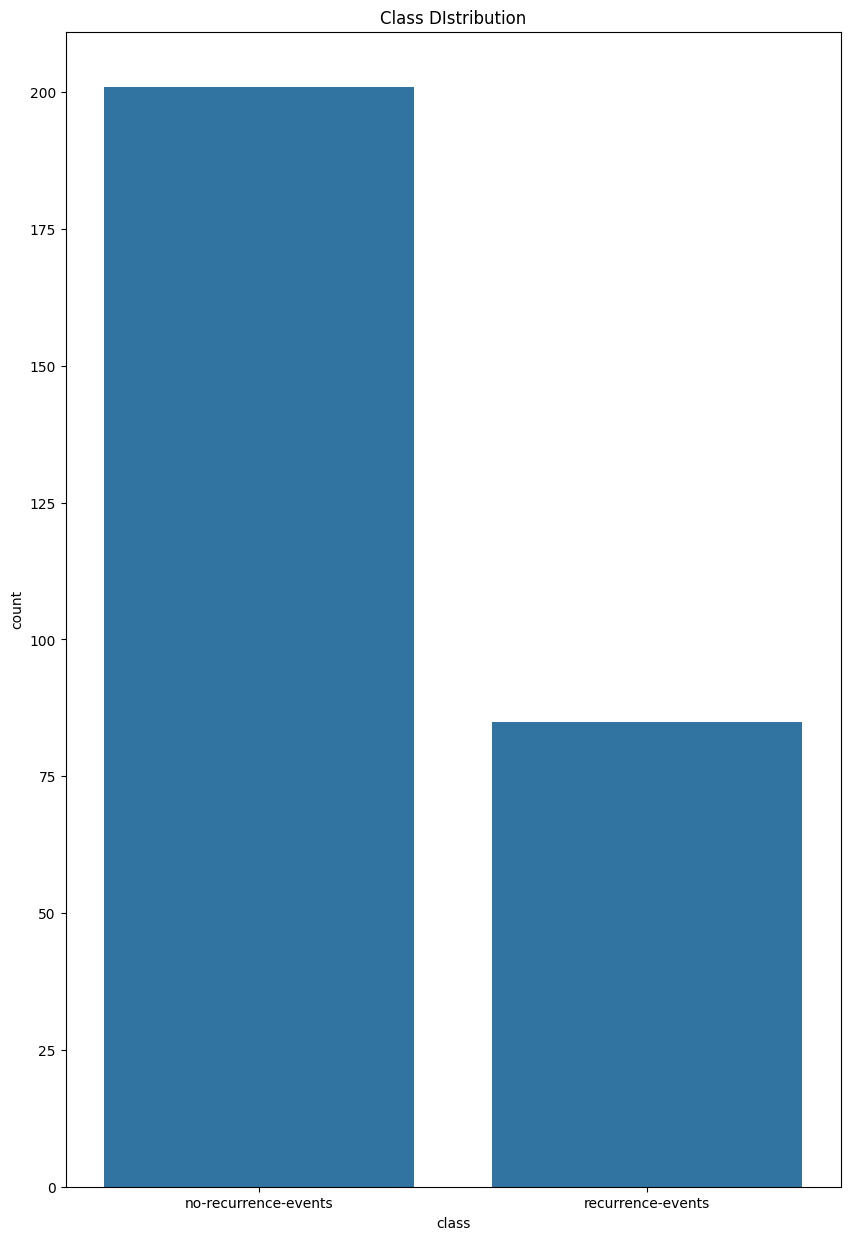

In [6]:
plt.figure(figsize=(10,15))
sns.countplot(x='class',data=df)
plt.title("Class DIstribution")
plt.show()

#### Cleaning Data

In [7]:
print((df == '?').sum())
df.isnull().sum()

class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      8
deg_malig      0
breast         0
breast_quad    1
irradiat       0
dtype: int64


,0
class,0
age,0
menopause,0
tumor_size,0
inv_nodes,0
node_caps,0
deg_malig,0
breast,0
breast_quad,0
irradiat,0


In [8]:
df.replace('?', np.nan, inplace=True)
df['node_caps'] = df['node_caps'].fillna(df['node_caps'].mode()[0])
df['breast_quad'] = df['breast_quad'].fillna(df['breast_quad'].mode()[0])

print("Jumlah NaN setelah diisi:")
print(df.isnull().sum())

Jumlah NaN setelah diisi:
class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      0
deg_malig      0
breast         0
breast_quad    0
irradiat       0
dtype: int64


### Label & Feature Encoding

In [9]:
X = df.drop("class", axis=1)
y = df["class"]

In [10]:
categorical_cols = X.columns

ct = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(), categorical_cols)
    ],
    remainder="passthrough"
)

X = ct.fit_transform(X)

In [11]:
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])



### Feature Correlation Check

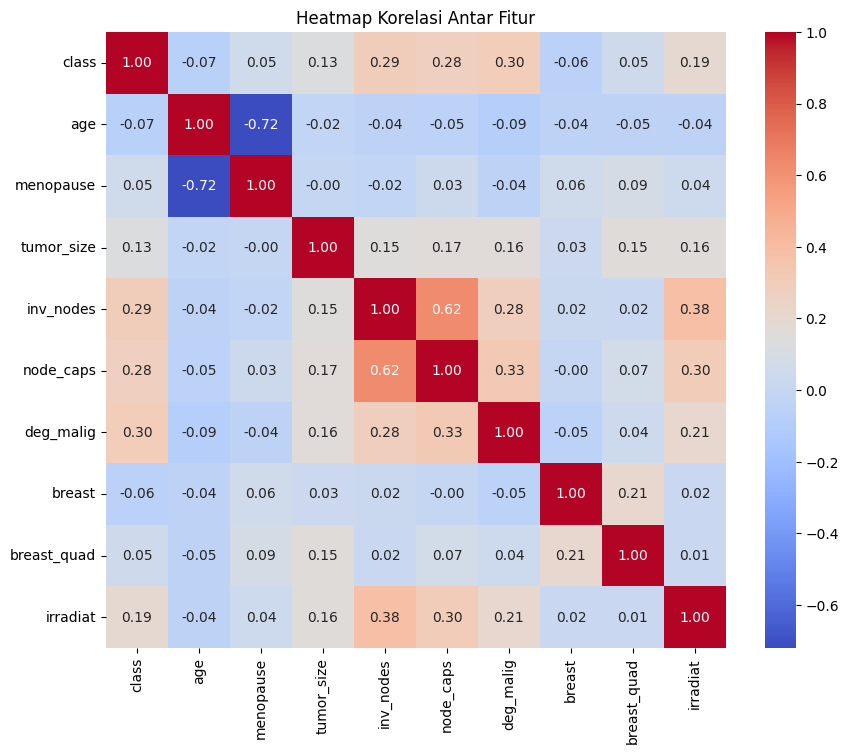

In [12]:
plt.figure(figsize=(10,8))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [ ]:
df.head()

,class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


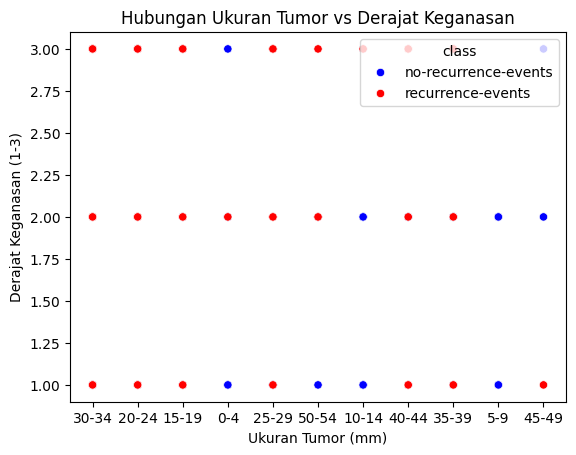

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='tumor_size',
    y='deg_malig',
    hue='class',
    palette={'recurrence-events':'red', 'no-recurrence-events':'blue'}
)

plt.title("Hubungan Ukuran Tumor vs Derajat Keganasan")
plt.xlabel("Ukuran Tumor (mm)")
plt.ylabel("Derajat Keganasan (1-3)")
plt.show()

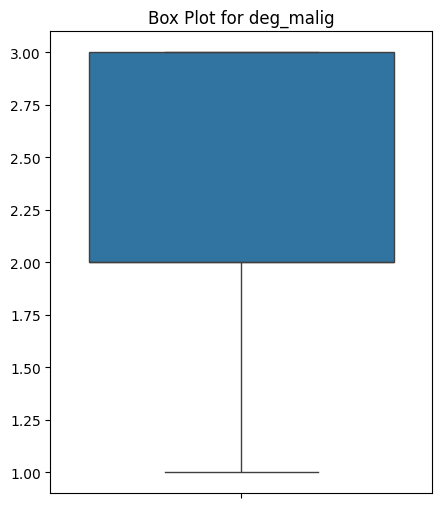

In [ ]:
import math

numeric_column = df.select_dtypes(include=['int64','float64']).columns

ncols = 4
nrows = math.ceil(len(numeric_column) / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 5*nrows))

axs = axs.flatten()

for i, column in enumerate(numeric_column):
    sns.boxplot(y=df[column], ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=0.5)
plt.show()

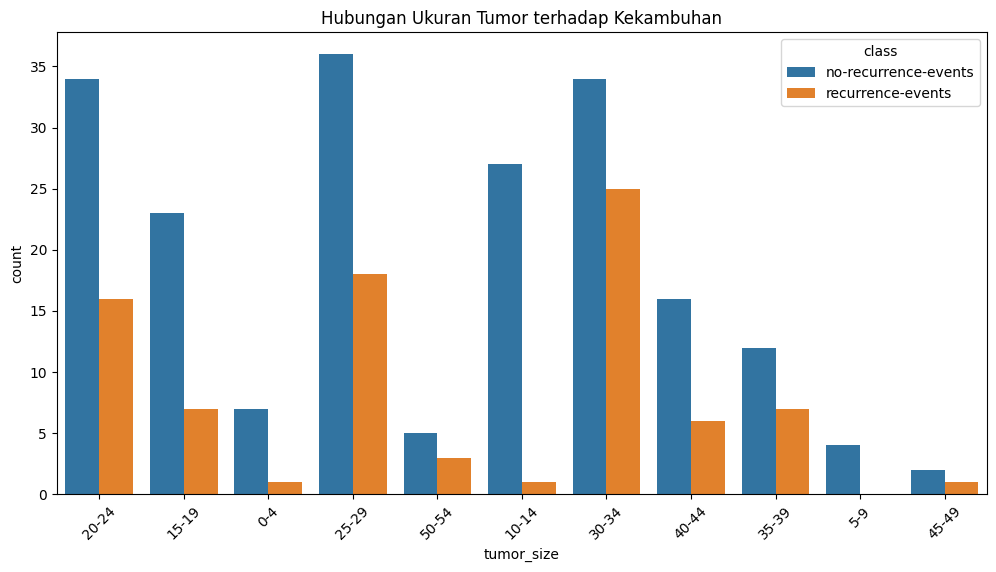

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='tumor_size', hue='class', data=df)
plt.title('Hubungan Ukuran Tumor terhadap Kekambuhan')
plt.xticks(rotation=45)
plt.show()



### Data Preparation

#### Check Outliers

        Column  Outliers  Loss %
8     irradiat        68   23.78
3    inv_nodes        64   22.38
4    node_caps        64   22.38
7  breast_quad        34   11.89
2   tumor_size        12    4.20
0          age         7    2.45
1    menopause         0    0.00
6       breast         0    0.00
5    deg_malig         0    0.00


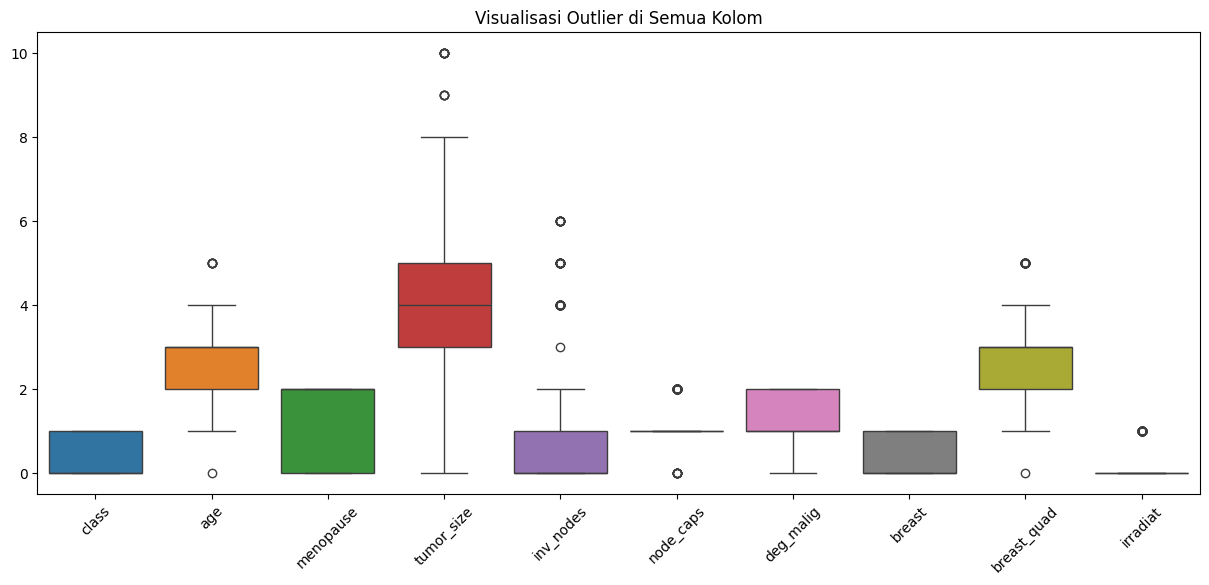

In [ ]:

outlier_data = []

for column in df_encoded.columns:
    if column == 'class':
        continue

    Q1 = df_encoded[column].quantile(0.25)
    Q3 = df_encoded[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df_encoded[column] < lower_bound) | (df_encoded[column] > upper_bound)).sum()
    total_count = len(df_encoded)
    loss_percentage = (outlier_count / total_count) * 100

    outlier_data.append({
        'Column': column,
        'Outliers': outlier_count,
        'Loss %': round(loss_percentage, 2)
    })

df_outliers = pd.DataFrame(outlier_data)
print(df_outliers.sort_values(by='Outliers', ascending=False))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_encoded)
plt.xticks(rotation=45)
plt.title('Visualisasi Outlier di Semua Kolom')
plt.show()

### Scaling

irradiat
-0.558504    218
 1.790498     68
Name: count, dtype: int64


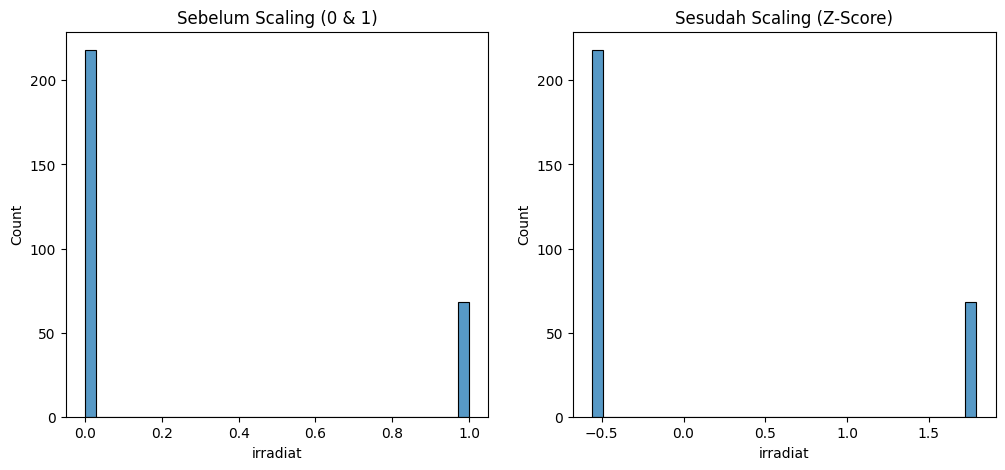

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
fitur = df_encoded.drop('class', axis=1)
nama_kolom = fitur.columns

fitur_scaled_array = scaler.fit_transform(fitur)

df_scaled = pd.DataFrame(fitur_scaled_array, columns=nama_kolom)
df_scaled['class'] = df_encoded['class'].values

print(df_scaled['irradiat'].value_counts())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_encoded['irradiat'], kde=False)
plt.title('Sebelum Scaling (0 & 1)')

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['irradiat'], kde=False)
plt.title('Sesudah Scaling (Z-Score)')

plt.show()

### Feature Selection

In [ ]:
selected_features = ['deg_malig', 'inv_nodes', 'node_caps', 'irradiat', 'tumor_size']

X = df_scaled[selected_features]
Y = df_scaled['class']

print("Variabel X (Fitur) siap dengan kolom:", selected_features)
print("Variabel Y (Target) siap.")

Variabel X (Fitur) siap dengan kolom: ['deg_malig', 'inv_nodes', 'node_caps', 'irradiat', 'tumor_size']
Variabel Y (Target) siap.


### Train Test Split

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y
)

model_weighted = RandomForestClassifier(
    n_estimators=300,        # Perbanyak pohon untuk stabilitas
    max_depth=8,             # Kedalaman menengah
    class_weight='balanced', # KUNCI: Menyeimbangkan tanpa nambah data buatan
    random_state=42
)

model_weighted.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42)

model.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!



HASIL EVALUASI MODEL
Akurasi Total: 72.41%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.54      0.41      0.47        17

    accuracy                           0.72        58
   macro avg       0.66      0.63      0.64        58
weighted avg       0.71      0.72      0.71        58



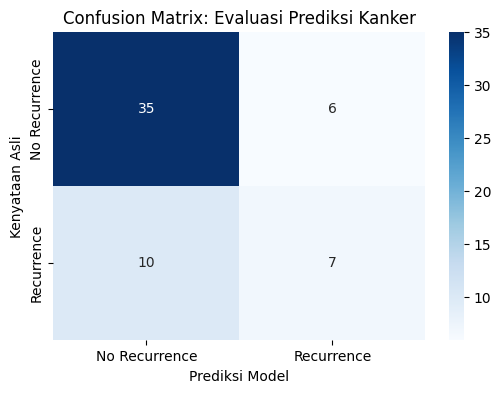

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = model.predict(X_test)

print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"Akurasi Total: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Recurrence', 'Recurrence'],
            yticklabels=['No Recurrence', 'Recurrence'])
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Asli')
plt.title('Confusion Matrix: Evaluasi Prediksi Kanker')
plt.show()